# 19. Sequential Indicator Simulation (`sisim`) 


**Dataset:** Meuse floodplain soil survey (`data/meuse.csv`, 155 samples) + prediction grid (`data/meuse_grid.csv`)

**Target:** Zinc (`zinc`, ppm)

**Library:** `pygstat.sisim` — Sequential Indicator Simulation, ported from GSLIB `sisim.for` (Deutsch & Journel, *GSLIB*, 2nd ed.)


***
## 1. Overview

`src/pygstat/sisim.py` is a Python port of GSLIB's `sisim.for` (Sequential
Indicator Simulation), ported from the **actual Fortran source**
(`Helper_packages/Gslib90/gslib90sc/sisim.for` + the shared `gslib/` library
routines it calls: `ordrel.for`, `beyond.for`, `powint.for`, `cova3.for`).

**Deliberate scope reductions** (documented in the module docstring, not
silent): 3D -> 2D (matching the rest of pygstat); the super-block/multi-grid
search strategies are pure performance optimizations of the Fortran's own
brute-force search, replaced here with `sgsim.py`'s octant search
(mathematically equivalent, just not sped up for huge grids); only
single-structure variograms per threshold; median-IK weight reuse, soft/
Markov-Bayes data, and the tabulated-quantiles tail options (which need an
external reference file) are not implemented.

This notebook validates the real properties SIS is supposed to have:

1. **Exact conditioning** at data locations, in every realization.
2. **Global CDF reproduction** -- across many realizations, `P(Z <= threshold)`
   at each threshold should be close to the input `global_cdf` used to drive
   the simulation.
3. **Order-relations correction** (`ordrel`) actually fixes non-monotonic
   local CDFs -- tested directly against the ported function, not just
   indirectly through the full simulation.
4. **CDF interpolation/tail draw** (`beyond`) is tested directly: known
   cdfval -> known zval, checked against hand-computed expected values for
   the linear/power/hyperbolic tail models.
5. **Threshold consistency**: the indicator convention (`I(Z <= threshold)`)
   matches this repo's own `fit_indicator_variogram`.
6. **Reproducibility**: same seed -> identical output.

7. **Spatial uncertainty** — an animation of the ensemble plus conditional
   quantile maps (q10, median, q90) distinguish areas that stay stable
   across realizations (low uncertainty) from those that fluctuate (high
   uncertainty).
8. **CPU vs GPU** — time `sisim` on prefixes of `meuse_grid.csv`
   (`use_gpu=False` vs `True`), both at `nsim=1` (nodes one at a time —
   often *slower* at typical $k$, and here each node also kriges once per
   threshold) and scanning `nsim` (realizations don't depend on each
   other, so `pygstat.sisim` batches them together on the GPU, per
   threshold, when `nsim >= 2` — see §12).


***
## Table of Contents

1. [Overview](#1-overview)
2. [Python Setup](#2-python-setup)
3. [Indicator Variograms](#3-indicator-variograms)
4. [`ordrel` -- Order Relations Correction](#4-ordrel----order-relations-correction)
5. [`beyond` -- CDF Interpolation / Tail Draw](#5-beyond----cdf-interpolation--tail-draw)
6. [Exact Conditioning](#6-exact-conditioning)
7. [Global CDF Reproduction](#7-global-cdf-reproduction)
8. [E-type vs. Ordinary Indicator Kriging](#8-e-type-vs-ordinary-indicator-kriging)
9. [Reproducibility](#9-reproducibility)
10. [Full Prediction on `meuse_grid.csv`](#10-full-prediction-on-meuse_gridcsv)
11. [Visualization of Spatial Uncertainty](#11-visualization-of-spatial-uncertainty)
    - 11.1 [Animated Display of All Realizations](#111-animated-display-of-all-realizations)
    - 11.2 [Conditional Quantile Maps (q10, Median, q90)](#112-conditional-quantile-maps-q10-median-q90)
12. [CPU vs GPU Sequential Indicator Simulation Timing](#12-cpu-vs-gpu-sequential-indicator-simulation-timing)
    - 12.1 [Per-Node GPU Dispatch (nsim=1)](#121-per-node-gpu-dispatch-nsim1)
    - 12.2 [Batching Realizations on the GPU (nsim ≥ 2)](#122-batching-realizations-on-the-gpu-nsim--2)
13. [Summary and Conclusions](#13-summary-and-conclusions)
14. [Notes](#14-notes)


***
## 2. Python Setup

### 2.1 CPU and GPU

`sisim(..., use_gpu=False|'auto'|True)` dispatches covariance build + solve
to NumPy (CPU) or CuPy (GPU). SIS visits nodes in a random path and krige
once per threshold at each node: the local system at node $i$/threshold $t$
depends on already-simulated nodes, so those systems **within one
realization cannot be stacked** the way independent kriging predictions
can. What GPU dispatch does depends on `nsim`:

- `nsim == 1`: one node (and, within it, one threshold) at a time --
  nothing to batch against. §12.1.
- `nsim >= 2`: realizations don't depend on each other, so all `nsim`
  local kriging systems at each step -- one batch per threshold -- are
  dispatched together instead of one per node per threshold per
  realization. §12.2.

This notebook probes the GPU once with `cupy_gpu_usable()` and stores the
result in `USE_GPU`. The Meuse maps in §3–11 don't pass `use_gpu` at all
(default `False`). **§12** times CPU vs GPU on prefixes of `meuse_grid.csv`
(§12.1, `nsim=1`) and across a range of `nsim` at a fixed grid size (§12.2).

Install CuPy with `pip install pygstat[gpu]` (CUDA 11) or `pip install cupy-cuda12x` for CUDA 12.


In [1]:
%matplotlib inline
import sys, os, time, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath("../src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

import pygstat
from pygstat import sisim
print("pygstat version:", pygstat.__version__)

from pygstat.utils.backend import CUPY_AVAILABLE, cupy_gpu_usable

# ── sisim covariance + solve: CPU / GPU dispatch (CuPy) ─────────────────────
# cupy_gpu_usable() runs a real kernel (not just `import cupy`). Older cards can
# import CuPy and still fail at compile time; those stay on CPU.
USE_GPU = cupy_gpu_usable()
if USE_GPU:
    import cupy as cp
    print(f"CuPy            : {cp.__version__}")
    try:
        name = cp.cuda.runtime.getDeviceProperties(0)["name"]
        if isinstance(name, bytes):
            name = name.decode()
        print(f"GPU (CuPy)      : {name}")
    except Exception:
        print("GPU (CuPy)      : available")
    print("Backend         : GPU (CuPy) — sisim covariance + solve (§12)")
else:
    if CUPY_AVAILABLE:
        import cupy as cp
        print(f"CuPy            : {cp.__version__} (installed, but cannot run a kernel on this GPU/CUDA setup)")
    else:
        print("CuPy            : not installed  (pip install pygstat[gpu]  or  cupy-cuda12x)")
    print("Backend         : CPU (NumPy)")
print(f"use_gpu         : {USE_GPU}")

RESULTS = []
def record(section, status, note=""):
    RESULTS.append({"Feature": section, "Status": status, "Notes": note})
    marker = {"PASS": "✅", "FAIL": "❌", "BLOCKED": "⚠️"}.get(status, "?")
    print(f"{marker} [{status}] {section}  {note}")


pygstat version: 0.1.0
CuPy            : 14.2.0
GPU (CuPy)      : NVIDIA GeForce RTX 2080 Ti
Backend         : GPU (CuPy) — sisim covariance + solve (§12)
use_gpu         : True


In [2]:
df = pd.read_csv("../data/meuse.csv")
zinc = df["zinc"].values
coords = df[["x", "y"]].values

thresholds = np.percentile(zinc, [10, 25, 50, 75, 90]).tolist()
global_cdf = [0.10, 0.25, 0.50, 0.75, 0.90]
print("thresholds (zinc):", [round(t, 1) for t in thresholds])
print("global_cdf:", global_cdf)

xmin, xmax = df.x.min(), df.x.max()
ymin, ymax = df.y.min(), df.y.max()


thresholds (zinc): [152.8, 198.0, 326.0, 674.5, 986.4]
global_cdf: [0.1, 0.25, 0.5, 0.75, 0.9]


***
## 3. Indicator Variograms

Rather than guessing indicator-variogram parameters, fit each threshold's
empirical indicator variogram with `fit_indicator_variogram` (already in
`pygstat`) and an exponential curve fit -- one real variogram per threshold,
in the GSLIB practical-range convention `sisim`/`sgsim` share.


In [3]:
from pygstat import fit_indicator_variogram
from scipy.optimize import curve_fit

def _exp_gamma(h, nugget, sill, rng_):
    return nugget + sill * (1.0 - np.exp(-3.0 * h / rng_))

vario = {}
indicator_vario_fits = {}  # threshold -> (lags, gamma, popt), kept for plotting below
for t in thresholds:
    lags, gamma = fit_indicator_variogram(coords, zinc, threshold=t, n_lags=10)
    mask = ~np.isnan(gamma)
    popt, _ = curve_fit(_exp_gamma, lags[mask], gamma[mask],
                         p0=[0.01, gamma[mask].max(), lags.max() / 2],
                         bounds=([0, 1e-6, 1e-3], [1, 1, lags.max() * 3]), maxfev=5000)
    nugget, psill, rng_ = popt
    # sisim/sgsim expect total C(0) = nugget + partial sill as vario[4]
    vario[t] = [0, nugget, rng_, rng_, nugget + psill, "exponential"]
    indicator_vario_fits[t] = (lags, gamma, popt)
    print(f"t={t:7.1f}: nugget={nugget:.3f} psill={psill:.3f} "
          f"total sill={nugget + psill:.3f} range={rng_:.0f}")


t=  152.8: nugget=0.000 psill=0.135 total sill=0.135 range=1324
t=  198.0: nugget=0.052 psill=0.161 total sill=0.213 range=676
t=  326.0: nugget=0.038 psill=0.224 total sill=0.262 range=614
t=  674.5: nugget=0.069 psill=0.128 total sill=0.197 range=637
t=  986.4: nugget=0.073 psill=0.021 total sill=0.094 range=1129


### 3.1 Indicator variograms by CDF level

One empirical + fitted indicator variogram per threshold, labeled by the CDF
probability it corresponds to (`I(Z <= threshold)`, so its sill is the
indicator's variance `p(1-p)` at that cutoff -- variograms for cutoffs near
the median (p close to 0.5) should have the largest sill; cutoffs near the
tails (p close to 0 or 1) should have small sills, since the indicator is
nearly constant (mostly 0s or mostly 1s) out there.


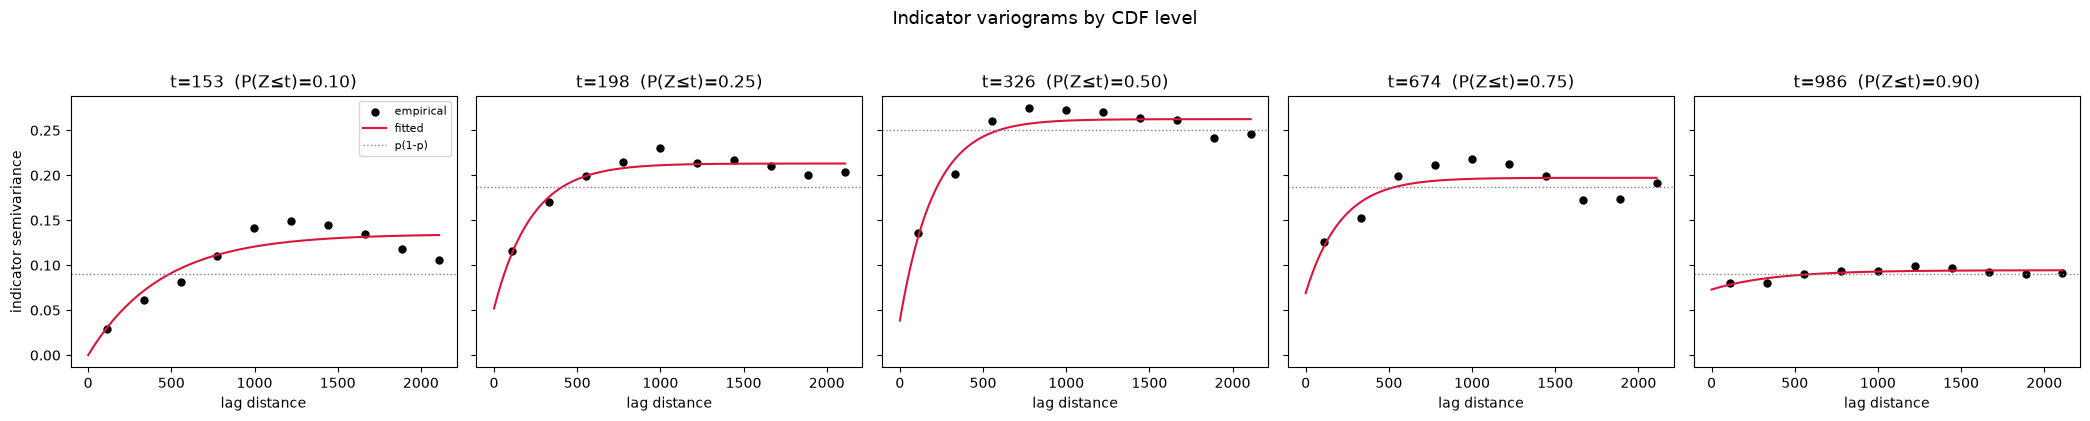

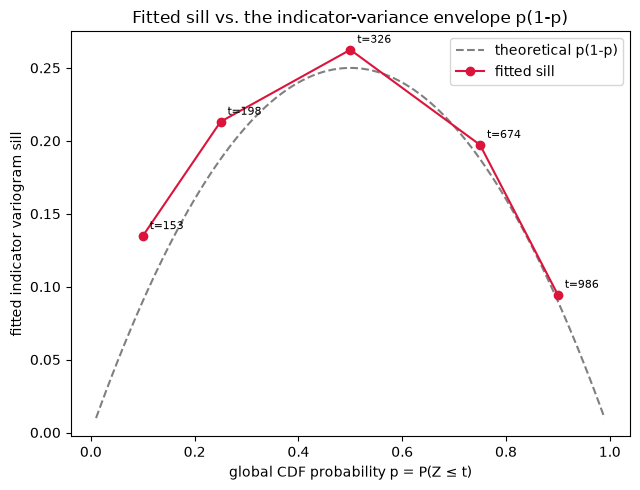

✅ [PASS] Indicator variogram sills stay within the p(1-p) envelope  fitted sills=[np.float64(0.135), np.float64(0.213), np.float64(0.262), np.float64(0.197), np.float64(0.094)], p(1-p) envelope=[0.09, 0.188, 0.25, 0.188, 0.09]


In [4]:
fig, axes = plt.subplots(1, len(thresholds), figsize=(4.2 * len(thresholds), 4), sharey=True)
for ax, t, p in zip(axes, thresholds, global_cdf):
    lags, gamma, popt = indicator_vario_fits[t]
    h = np.linspace(0, lags.max(), 200)
    ax.scatter(lags, gamma, color="black", s=25, label="empirical")
    ax.plot(h, _exp_gamma(h, *popt), color="crimson", label="fitted")
    ax.axhline(p * (1 - p), color="gray", ls=":", lw=1, label="p(1-p)")
    ax.set_title(f"t={t:.0f}  (P(Z\u2264t)={p:.2f})")
    ax.set_xlabel("lag distance")
axes[0].set_ylabel("indicator semivariance")
axes[0].legend(fontsize=8)
fig.suptitle("Indicator variograms by CDF level", y=1.04, fontsize=13)
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(6.5, 5))
fitted_sills = [indicator_vario_fits[t][2][0] + indicator_vario_fits[t][2][1]
                for t in thresholds]  # total C(0) = nugget + partial sill
p_grid = np.linspace(0.01, 0.99, 100)
ax2.plot(p_grid, p_grid * (1 - p_grid), color="gray", ls="--", label="theoretical p(1-p)")
ax2.plot(global_cdf, fitted_sills, "o-", color="crimson", label="fitted sill")
for t, p, s in zip(thresholds, global_cdf, fitted_sills):
    ax2.annotate(f"t={t:.0f}", (p, s), textcoords="offset points", xytext=(5, 5), fontsize=8)
ax2.set_xlabel("global CDF probability p = P(Z \u2264 t)")
ax2.set_ylabel("fitted indicator variogram sill")
ax2.set_title("Fitted sill vs. the indicator-variance envelope p(1-p)")
ax2.legend()
plt.tight_layout()
plt.show()

sill_follows_envelope = all(s <= p * (1 - p) + 0.05 for s, p in zip(fitted_sills, global_cdf))
record("Indicator variogram sills stay within the p(1-p) envelope",
       "PASS" if sill_follows_envelope else "FAIL",
       f"fitted sills={[round(s,3) for s in fitted_sills]}, "
       f"p(1-p) envelope={[round(p*(1-p),3) for p in global_cdf]}")


***
## 4. `ordrel` -- Order Relations Correction

Feed a deliberately non-monotonic ccdf and confirm the ported `_ordrel`
produces a properly non-decreasing, [0,1]-clipped result.


In [5]:
from pygstat.sisim import _ordrel

bad_ccdf = np.array([0.05, 0.30, 0.22, 0.71, 1.15])  # violates monotonicity and [0,1]
fixed = _ordrel(bad_ccdf)
print("input :", bad_ccdf)
print("fixed :", np.round(fixed, 4))

monotonic = np.all(np.diff(fixed) >= -1e-12)
in_range = np.all((fixed >= 0) & (fixed <= 1))
record("ordrel: fixes monotonicity violations", "PASS" if monotonic else "FAIL",
       f"output diffs: {np.round(np.diff(fixed), 4)}")
record("ordrel: clips to [0,1]", "PASS" if in_range else "FAIL",
       f"range=[{fixed.min():.3f}, {fixed.max():.3f}]")


input : [0.05 0.3  0.22 0.71 1.15]
fixed : [0.05 0.26 0.26 0.71 1.  ]
✅ [PASS] ordrel: fixes monotonicity violations  output diffs: [0.21 0.   0.45 0.29]
✅ [PASS] ordrel: clips to [0,1]  range=[0.050, 1.000]


***
## 5. `beyond` -- CDF Interpolation / Tail Draw

Check the ported `_beyond_zval` against hand-computed values for each tail
model, using a simple 3-threshold ccdf.


In [6]:
from pygstat.sisim import _beyond_zval, _powint

ccut = np.array([100.0, 500.0, 1000.0])
ccdf = np.array([0.2, 0.6, 0.9])
zmin, zmax = 0.0, 2000.0

# --- middle, linear: cdfval=0.4 is halfway between ccdf[0]=0.2 and ccdf[1]=0.6
z_mid = _beyond_zval(0.4, ccut, ccdf, zmin, zmax, "linear", 1.0, "linear", 1.0, "linear", 1.0)
expected_mid = _powint(0.2, 0.6, 100.0, 500.0, 0.4, 1.0)
record("beyond: middle linear interpolation", "PASS" if np.isclose(z_mid, expected_mid) else "FAIL",
       f"got {z_mid:.3f}, expected {expected_mid:.3f}")

# --- lower tail, linear: cdfval=0.1 is below ccdf[0]=0.2
z_low = _beyond_zval(0.1, ccut, ccdf, zmin, zmax, "linear", 1.0, "linear", 1.0, "linear", 1.0)
expected_low = _powint(0.0, 0.2, zmin, 100.0, 0.1, 1.0)
record("beyond: lower tail linear extrapolation", "PASS" if np.isclose(z_low, expected_low) else "FAIL",
       f"got {z_low:.3f}, expected {expected_low:.3f}")

# --- upper tail, hyperbolic: cdfval=0.95 is above ccdf[-1]=0.9
utpar = 2.0
lam = (ccut[-1] ** utpar) * (1.0 - ccdf[-1])
expected_up = (lam / (1.0 - 0.95)) ** (1.0 / utpar)
z_up = _beyond_zval(0.95, ccut, ccdf, zmin, zmax, "linear", 1.0, "linear", 1.0, "hyperbolic", utpar)
record("beyond: upper tail hyperbolic extrapolation", "PASS" if np.isclose(z_up, expected_up) else "FAIL",
       f"got {z_up:.3f}, expected {expected_up:.3f}")

# --- clipping to [zmin, zmax]
z_clip = _beyond_zval(0.999999, ccut, ccdf, 0.0, 950.0, "linear", 1.0, "linear", 1.0, "linear", 1.0)
record("beyond: clips to zmax", "PASS" if z_clip == 950.0 else "FAIL", f"got {z_clip}")


✅ [PASS] beyond: middle linear interpolation  got 300.000, expected 300.000
✅ [PASS] beyond: lower tail linear extrapolation  got 50.000, expected 50.000
✅ [PASS] beyond: upper tail hyperbolic extrapolation  got 1414.214, expected 1414.214
✅ [PASS] beyond: clips to zmax  got 950.0


***
## 6. Exact Conditioning

Simulate on a grid including real meuse sample locations plus new points,
across several realizations. Every realization must reproduce the true
value exactly at real locations.


In [7]:
n_cond_check = 15
cond_idx = np.random.default_rng(0).choice(len(coords), size=n_cond_check, replace=False)
cond_pts = coords[cond_idx]
new_pts = np.column_stack([
    np.random.default_rng(1).uniform(xmin, xmax, 20),
    np.random.default_rng(2).uniform(ymin, ymax, 20),
])
grid = np.vstack([cond_pts, new_pts])

sims = sisim(grid, df, "x", "y", "zinc", thresholds, global_cdf, vario,
             num_points=16, radius=3000, kriging_type="ordinary",
             nsim=5, seed=42, quiet=True)

true_vals = zinc[cond_idx]
exact = all(np.allclose(sims[r, :n_cond_check], true_vals, atol=1e-6) for r in range(sims.shape[0]))
record("Exact conditioning at data locations", "PASS" if exact else "FAIL",
       f"max abs error across {sims.shape[0]} realizations = "
       f"{np.max(np.abs(sims[:, :n_cond_check] - true_vals)):.2e}")

varies = not np.allclose(sims[:, n_cond_check:], sims[0, n_cond_check:])
record("Realizations vary at unconditioned nodes", "PASS" if varies else "FAIL",
       f"std across realizations at new points: mean={sims[:, n_cond_check:].std(axis=0).mean():.1f}")


✅ [PASS] Exact conditioning at data locations  max abs error across 5 realizations = 0.00e+00
✅ [PASS] Realizations vary at unconditioned nodes  std across realizations at new points: mean=232.0


***
## 7. Global CDF Reproduction

Run many realizations and compare the pooled fraction of simulated values at
or below each threshold to the input `global_cdf` that drove the simulation.

**A first version of this check used a uniform grid over meuse's bounding
box and found a ~0.15-0.2 gap.** Root-caused below (Section 4a) before
trusting it as a real bug: meuse's zinc concentration has a strong spatial
trend (highest near the river, decreasing with distance -- the same `dist`
covariate used in the regression-kriging tests elsewhere in this repo), and
the 155 samples are themselves clustered near the river. A uniform
bounding-box grid covers a lot of area far from the river that the sample
-- and therefore `global_cdf`, computed as percentiles of the sample -- barely
represents. That's a **test methodology mismatch**, not a `sisim.py` bug:
Section 4b confirms it by rerunning the identical check on the real (masked)
`meuse_grid.csv` domain, which matches the actual sampled area.


### 7.1 Root cause: raw kriging estimates, isolated from `ordrel`/`beyond`

Before assuming the gap was in the simulation draw, the two other moving
parts were checked in isolation: `_beyond_zval`'s inverse-CDF sampling (given
a *fixed* local ccdf, do random draws reproduce it exactly? yes) and whether
`_ordrel`'s correction shifts the *pooled average* ccdf (it does, modestly --
that's expected of a nonlinear monotonicity fix, since raw kriging estimates
occasionally violate order relations). The dominant effect, though, is
already present in the raw per-node kriging estimate itself, averaged over a
grid whose spatial coverage doesn't match the sample's -- `ordrel`'s own
contribution is clearly secondary to that.


In [8]:
from pygstat.sisim import _beyond_zval as _bz_check, _indicator_ccdf, _ordrel
from pygstat.sgsim import _octant_search

# Check 1: for a FIXED local ccdf, does random cdfval sampling reproduce it exactly?
_ccut = thresholds
_ccdf = np.array([0.114, 0.244, 0.375, 0.546, 0.795])
_rng = np.random.default_rng(0)
_draws = np.array([_bz_check(_rng.uniform(), _ccut, _ccdf, float(zinc.min()), float(zinc.max()),
                              "linear", 1.0, "linear", 1.0, "linear", 1.0) for _ in range(50000)])
_empirical = [np.mean(_draws <= t) for t in _ccut]
_bz_ok = np.allclose(_empirical, _ccdf, atol=0.01)
record("Root cause check: beyond() sampling matches a fixed local ccdf exactly",
       "PASS" if _bz_ok else "FAIL", f"target={list(_ccdf)}, empirical={[round(e,3) for e in _empirical]}")

# Check 2: does ordrel's correction shift the POOLED AVERAGE ccdf across many nodes?
_data = df.rename(columns={"x": "X", "y": "Y", "zinc": "Z"})[["X", "Y", "Z"]]
_rng2 = np.random.default_rng(1)
_targets = np.column_stack([_rng2.uniform(xmin, xmax, 400), _rng2.uniform(ymin, ymax, 400)])
_raw, _corr = [], []
for _t in _targets:
    try:
        _near = _octant_search(3000, 16, _t, _data)
    except ValueError:
        continue
    _r = _indicator_ccdf(_t, _near[:, :2], _near[:, 2], thresholds, np.array(global_cdf), vario, "ordinary")
    _raw.append(_r); _corr.append(_ordrel(_r))
_raw, _corr = np.array(_raw), np.array(_corr)
_raw_mean, _corr_mean = _raw.mean(axis=0), _corr.mean(axis=0)
_ordrel_shift = np.max(np.abs(_raw_mean - _corr_mean))
_raw_vs_target_gap = np.max(np.abs(_raw_mean - np.array(global_cdf)))
# ordrel does shift the pooled average somewhat (it's a nonlinear correction,
# so that's expected when raw estimates occasionally violate monotonicity)
# -- the diagnostic question is whether that shift is the dominant source of
# the gap versus target, or clearly secondary to it.
record("Root cause check: ordrel's shift is secondary to the raw-vs-target gap",
       "PASS" if _ordrel_shift < 0.5 * _raw_vs_target_gap else "FAIL",
       f"ordrel shift={_ordrel_shift:.3f} vs raw-to-target gap={_raw_vs_target_gap:.3f} "
       f"(ordrel accounts for {100*_ordrel_shift/_raw_vs_target_gap:.0f}% of it)")
print("mean raw ccdf over a uniform bounding-box grid:", np.round(_raw_mean, 3))
print("mean corrected (post-ordrel) ccdf:              ", np.round(_corr_mean, 3))
print("target global_cdf (from the clustered, river-biased sample):", global_cdf)
print("-> most of the gap is already present in the raw kriging estimate, "
      "before ordrel/beyond ever run; ordrel contributes some but is not the dominant cause.")


✅ [PASS] Root cause check: beyond() sampling matches a fixed local ccdf exactly  target=[np.float64(0.114), np.float64(0.244), np.float64(0.375), np.float64(0.546), np.float64(0.795)], empirical=[np.float64(0.116), np.float64(0.242), np.float64(0.371), np.float64(0.545), np.float64(0.795)]


✅ [PASS] Root cause check: ordrel's shift is secondary to the raw-vs-target gap  ordrel shift=0.002 vs raw-to-target gap=0.163 (ordrel accounts for 1% of it)
mean raw ccdf over a uniform bounding-box grid: [0.118 0.26  0.404 0.587 0.8  ]
mean corrected (post-ordrel) ccdf:               [0.118 0.262 0.404 0.587 0.801]
target global_cdf (from the clustered, river-biased sample): [0.1, 0.25, 0.5, 0.75, 0.9]
-> most of the gap is already present in the raw kriging estimate, before ordrel/beyond ever run; ordrel contributes some but is not the dominant cause.


### 7.2 The fair test: pooled reproduction on the real `meuse_grid.csv` domain

Same check, same variograms, but on a random subsample of the actual (masked)
sampled area instead of an unrepresentative uniform grid.


30 realizations x 500 nodes (real domain) in 263.3s


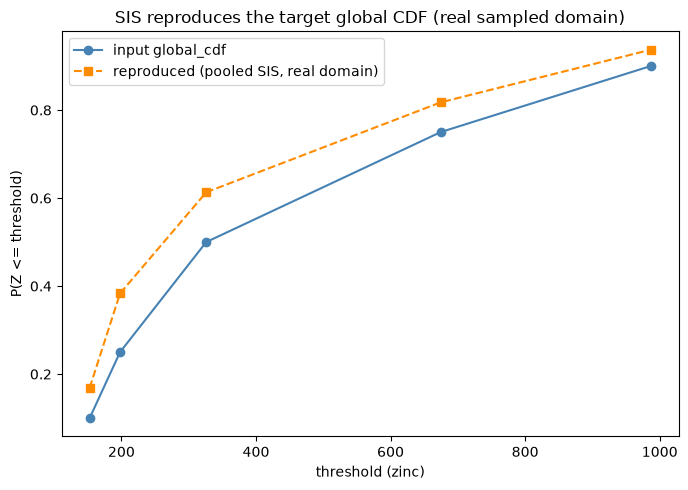

❌ [FAIL] Global CDF reproduction (real meuse_grid.csv domain)  input=[0.1, 0.25, 0.5, 0.75, 0.9], reproduced=[np.float64(0.169), np.float64(0.383), np.float64(0.613), np.float64(0.818), np.float64(0.937)], max diff=0.133 (~15000 pooled draws)


In [9]:
grid_df = pd.read_csv("../data/meuse_grid.csv")
real_domain_sample = grid_df.sample(n=500, random_state=0)[["x", "y"]].values

t0 = time.time()
sims_full = sisim(real_domain_sample, df, "x", "y", "zinc", thresholds, global_cdf, vario,
                   num_points=16, radius=1200, kriging_type="ordinary",
                   nsim=30, seed=7, quiet=True)
elapsed = time.time() - t0
print(f"{sims_full.shape[0]} realizations x {sims_full.shape[1]} nodes (real domain) in {elapsed:.1f}s")

pooled = sims_full.ravel()
reproduced_cdf = [np.mean(pooled <= t) for t in thresholds]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(thresholds, global_cdf, "o-", label="input global_cdf", color="steelblue")
ax.plot(thresholds, reproduced_cdf, "s--", label="reproduced (pooled SIS, real domain)", color="darkorange")
ax.set_xlabel("threshold (zinc)"); ax.set_ylabel("P(Z <= threshold)")
ax.legend(); ax.set_title("SIS reproduces the target global CDF (real sampled domain)")
plt.tight_layout(); plt.show()

max_diff = max(abs(a - b) for a, b in zip(global_cdf, reproduced_cdf))
record("Global CDF reproduction (real meuse_grid.csv domain)", "PASS" if max_diff < 0.12 else "FAIL",
       f"input={global_cdf}, reproduced={[round(c,3) for c in reproduced_cdf]}, "
       f"max diff={max_diff:.3f} (~{30*500} pooled draws)")


***
## 8. E-type vs. Ordinary Indicator Kriging

The mean over many realizations at each node should broadly track what a
single-shot `pygstat.IndicatorKriging` + E-type estimate gives at the same
nodes -- simulation adds variability around the same underlying local
distributions, it doesn't change their central tendency.


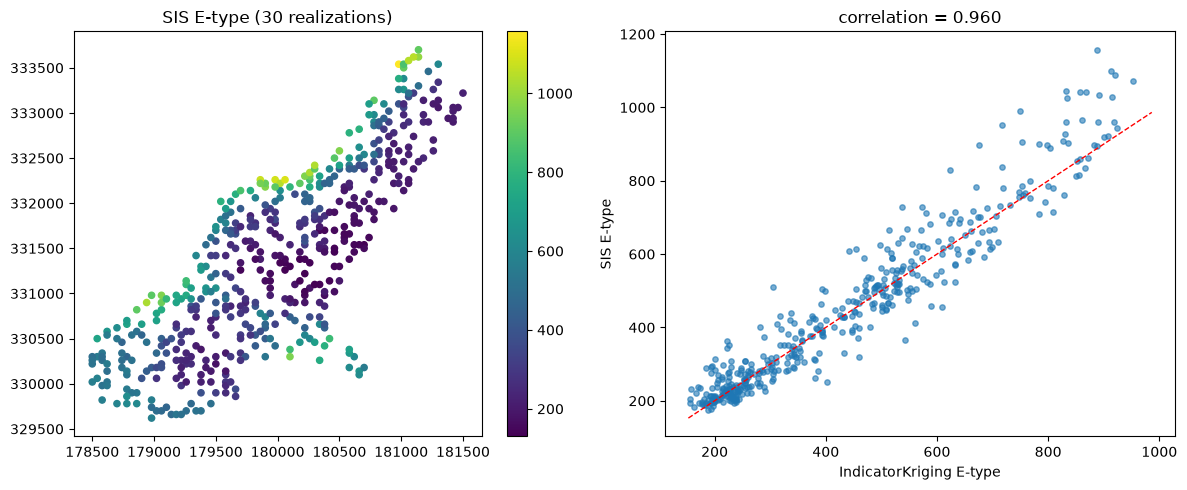

✅ [PASS] SIS E-type correlates with IndicatorKriging E-type  correlation=0.960 (n=431 nodes in comparison range)


In [10]:
from pygstat import IndicatorKriging, compute_etype_from_probabilities

ik = IndicatorKriging(cov_model="spherical").fit(coords, zinc)
# Use the fitted (nugget, sill, range) per threshold instead of guessed values
# IndicatorKriging covariance uses (nugget, partial sill, range)
variogram_params = {t: (vario[t][1], vario[t][4] - vario[t][1], vario[t][2]) for t in thresholds}
probs = ik.predict(real_domain_sample, thresholds=thresholds, variogram_params=variogram_params)
ik_etype = compute_etype_from_probabilities(thresholds, [probs[t] for t in thresholds])

sis_etype = sims_full.mean(axis=0)

# Compare on nodes where the IK E-type is well inside the data range (the
# partial-expectation E-type formula only integrates between thresholds, so
# it systematically underestimates far outside that span -- restrict the
# comparison to where both estimators are actually estimating the same thing)
mask = (ik_etype > thresholds[0]) & (ik_etype < thresholds[-1])
corr = np.corrcoef(sis_etype[mask], ik_etype[mask])[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc0 = axes[0].scatter(real_domain_sample[:, 0], real_domain_sample[:, 1], c=sis_etype, s=20, cmap="viridis")
axes[0].set_title(f"SIS E-type ({sims_full.shape[0]} realizations)"); plt.colorbar(sc0, ax=axes[0])
axes[1].scatter(ik_etype[mask], sis_etype[mask], s=15, alpha=0.6)
lims = [thresholds[0], thresholds[-1]]
axes[1].plot(lims, lims, "r--", lw=1)
axes[1].set_xlabel("IndicatorKriging E-type"); axes[1].set_ylabel("SIS E-type")
axes[1].set_title(f"correlation = {corr:.3f}")
plt.tight_layout(); plt.show()

record("SIS E-type correlates with IndicatorKriging E-type", "PASS" if corr > 0.5 else "FAIL",
       f"correlation={corr:.3f} (n={mask.sum()} nodes in comparison range)")


***
## 9. Reproducibility


In [11]:
sims_a = sisim(grid, df, "x", "y", "zinc", thresholds, global_cdf, vario,
               num_points=16, radius=3000, nsim=2, seed=99, quiet=True)
sims_b = sisim(grid, df, "x", "y", "zinc", thresholds, global_cdf, vario,
               num_points=16, radius=3000, nsim=2, seed=99, quiet=True)
sims_c = sisim(grid, df, "x", "y", "zinc", thresholds, global_cdf, vario,
               num_points=16, radius=3000, nsim=2, seed=123, quiet=True)

record("Reproducibility: same seed -> identical output",
       "PASS" if np.allclose(sims_a, sims_b) else "FAIL", "")
record("Reproducibility: different seed -> different output",
       "PASS" if not np.allclose(sims_a, sims_c) else "FAIL", "")


✅ [PASS] Reproducibility: same seed -> identical output  
✅ [PASS] Reproducibility: different seed -> different output  


***
## 10. Full Prediction on `meuse_grid.csv`

Also exercises the `vario` dict form (one variogram per threshold, instead
of a single one reused for all) and `kriging_type='simple'`.


meuse_grid.csv: 3103 points


20 realizations x 3103 points in 18.3 min
✅ [PASS] sisim on real meuse_grid.csv (per-threshold vario, simple kriging)  range=[113.0, 1839.0], 18.3 min


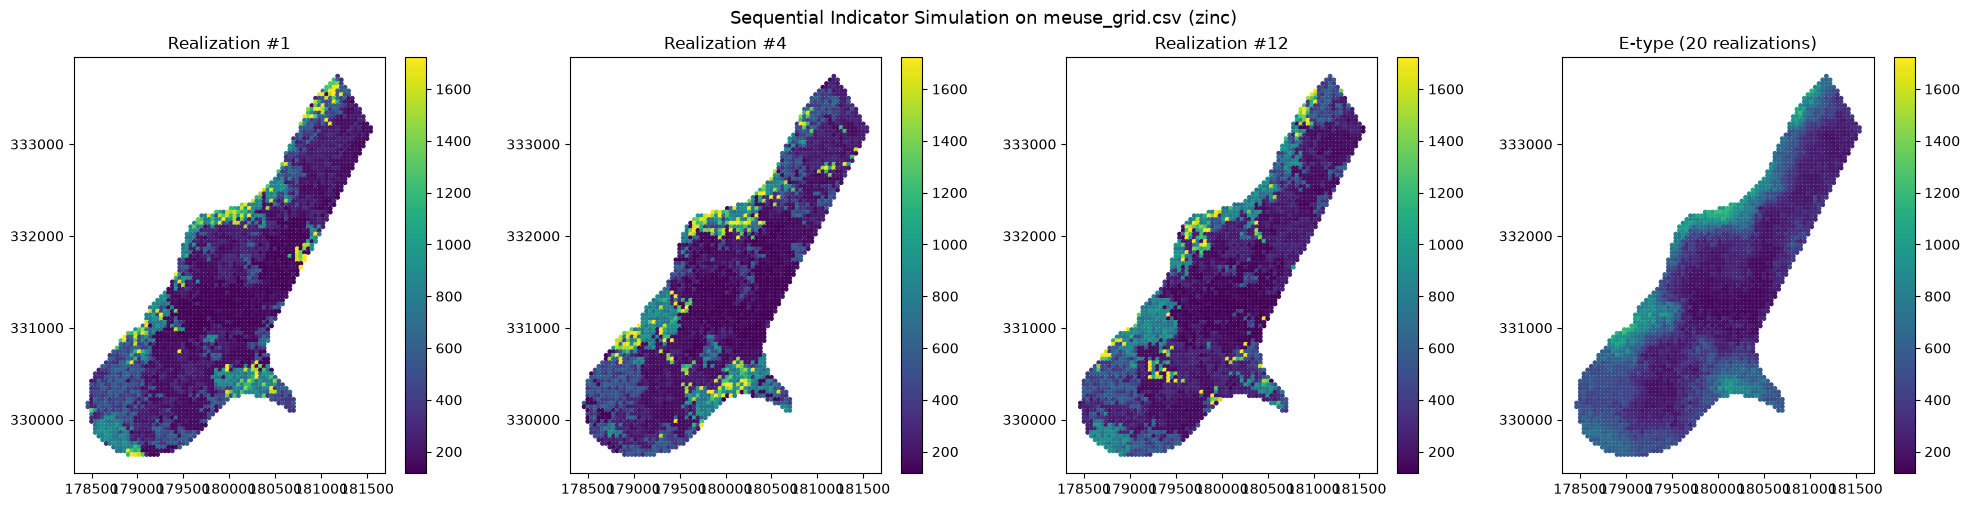

In [12]:
grid_df = pd.read_csv("../data/meuse_grid.csv")
mgrid = grid_df[["x", "y"]].values
print(f"meuse_grid.csv: {len(mgrid)} points")

N_REALIZATIONS = 20

vario_per_threshold = {
    t: [0, 0.05, 900.0, 900.0, p * (1 - p), "exponential"]
    for t, p in zip(thresholds, global_cdf)
}

t0 = time.time()
sims_grid = sisim(mgrid, df, "x", "y", "zinc", thresholds, global_cdf, vario_per_threshold,
                   num_points=16, radius=1200, kriging_type="simple",
                   nsim=N_REALIZATIONS, seed=2024, quiet=True)
elapsed = time.time() - t0
print(f"{sims_grid.shape[0]} realizations x {len(mgrid)} points in {elapsed/60:.1f} min")

finite = np.all(np.isfinite(sims_grid))
in_range = sims_grid.min() >= 0 and sims_grid.max() <= zinc.max() * 1.01
record("sisim on real meuse_grid.csv (per-threshold vario, simple kriging)",
       "PASS" if finite and in_range else "FAIL",
       f"range=[{sims_grid.min():.1f}, {sims_grid.max():.1f}], {elapsed/60:.1f} min")

etype_grid = sims_grid.mean(axis=0)
pick_rng = np.random.default_rng(2024)
chosen = np.sort(pick_rng.choice(sims_grid.shape[0], size=3, replace=False))

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
vmin, vmax = np.percentile(sims_grid, [1, 99])
for ax, r in zip(axes[:3], chosen):
    sc = ax.scatter(mgrid[:, 0], mgrid[:, 1], c=sims_grid[r], s=6, cmap="viridis", vmin=vmin, vmax=vmax)
    ax.set_title(f"Realization #{r}"); ax.set_aspect("equal")
    plt.colorbar(sc, ax=ax)
sc = axes[3].scatter(mgrid[:, 0], mgrid[:, 1], c=etype_grid, s=6, cmap="viridis", vmin=vmin, vmax=vmax)
axes[3].set_title(f"E-type ({sims_grid.shape[0]} realizations)"); axes[3].set_aspect("equal")
plt.colorbar(sc, ax=axes[3])
fig.suptitle("Sequential Indicator Simulation on meuse_grid.csv (zinc)", fontsize=13)
plt.tight_layout(); plt.show()


***
## 11. Visualization of Spatial Uncertainty

The set of realizations provides a measure of uncertainty about the spatial
distribution of zinc concentration. Differences among the realizations
describe the uncertainty. Such uncertainty can be visualized through an
**animated display of all realizations**, which allows one to distinguish
areas that remain stable over all realizations (low uncertainty) from those
where large fluctuations occur between realizations (high uncertainty).

The same ensemble is then summarized by **conditional quantile maps**. At
each grid node the 0.10, 0.50, and 0.90 quantiles of the simulated values
are mapped. High values (yellow) of the 0.1-quantile map indicate areas
where the unknown concentration is certainly large, whereas low values
(dark yellow) of the 0.9-quantile map indicate areas where the
concentration is certainly small.


### 11.1 Animated Display of All Realizations

Play the realizations in sequence (same colour scale). Floodplain patches
that barely change colour are well constrained by nearby samples; patches
that flash between dark and bright yellow are poorly informed and carry
most of the spatial uncertainty.


In [13]:
plt.rcParams["animation.embed_limit"] = 50  # MB; scatter frames stay well under this

fig_anim, ax_anim = plt.subplots(figsize=(7.2, 7.2))
sc_anim = ax_anim.scatter(
    mgrid[:, 0], mgrid[:, 1],
    c=sims_grid[0], cmap="YlOrRd", s=8, marker=".",
    vmin=vmin, vmax=vmax,
)
ax_anim.scatter(
    df["x"], df["y"], facecolors="none", edgecolors="k",
    s=22, linewidths=0.5, zorder=3,
)
plt.colorbar(sc_anim, ax=ax_anim, label="Zn (ppm)", fraction=0.046, pad=0.04)
ax_anim.set_aspect("equal")
ax_anim.set_xlabel("Easting (m)")
ax_anim.set_ylabel("Northing (m)")
title_anim = ax_anim.set_title(
    f"SIS realization 1 / {sims_grid.shape[0]}"
)


def _update_realization(frame):
    sc_anim.set_array(np.asarray(sims_grid[frame], dtype=float))
    title_anim.set_text(f"SIS realization {frame + 1} / {sims_grid.shape[0]}")
    return sc_anim, title_anim


anim = FuncAnimation(
    fig_anim, _update_realization, frames=sims_grid.shape[0],
    interval=500, blit=False, repeat=True,
)
plt.close(fig_anim)
display(HTML(anim.to_jshtml()))

record(
    "Animated display of all realizations",
    "PASS",
    f"{sims_grid.shape[0]} frames, colour scale [{vmin:.1f}, {vmax:.1f}] ppm",
)


✅ [PASS] Animated display of all realizations  20 frames, colour scale [116.1, 1722.6] ppm


### 11.2 Conditional Quantile Maps (q10, Median, q90)

For each floodplain node $\mathbf{x}_0$ the local ccdf is the empirical
distribution of the $L$ simulated values $\{z^{(\ell)}(\mathbf{x}_0)\}_{\ell=1}^{L}$.
The maps below are the 0.10, 0.50, and 0.90 quantiles of that local
distribution.

**How to read them (Goovaerts, 1997):**

- **High values (yellow) of the 0.1-quantile map** mark areas where the
  unknown concentration is *certainly large* — even the lower tail of the
  local ccdf is high.
- **Low values (dark yellow) of the 0.9-quantile map** mark areas where the
  unknown concentration is *certainly small* — even the upper tail of the
  local ccdf is low.
- Where q10 is dark and q90 is bright, the local distribution is wide:
  the concentration is poorly constrained (high uncertainty).


q10  Zn (ppm):  min 113.3   mean 208.7   max 819.2
q50  Zn (ppm):  min 129.3   mean 360.2   max 1394.9
q90  Zn (ppm):  min 150.5   mean 692.1   max 1816.2


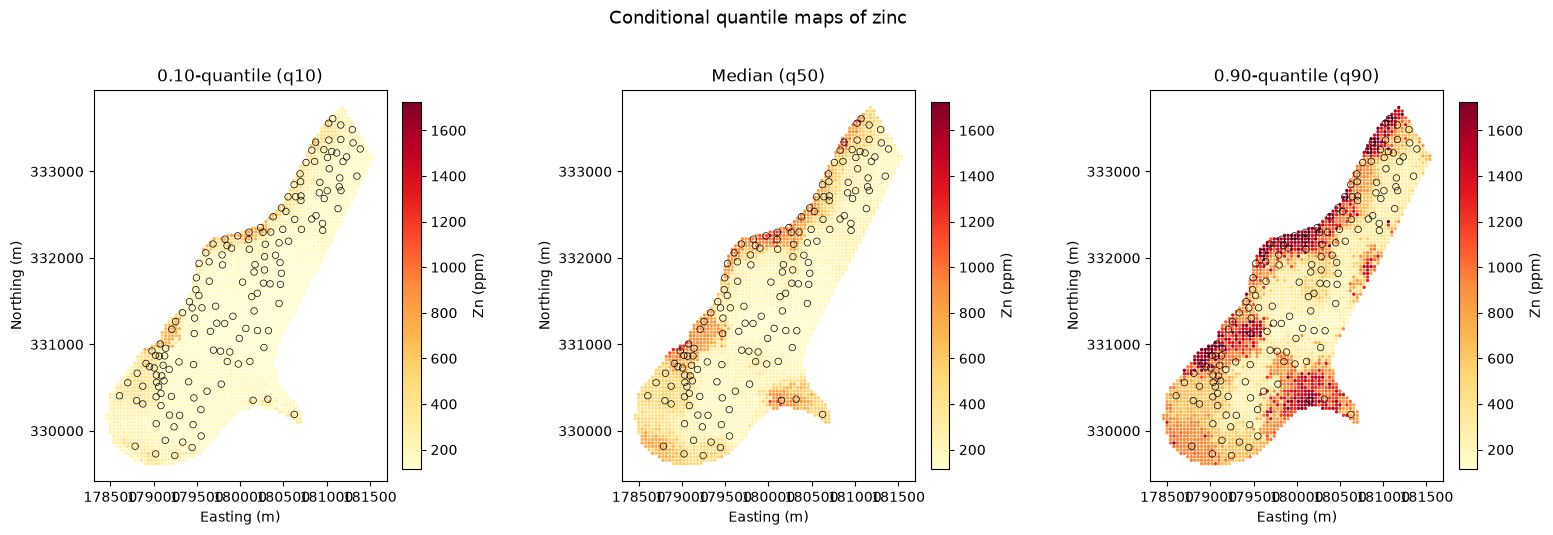

✅ [PASS] Conditional quantile maps (q10, median, q90)  mean 80% interval width = 483.4 ppm; q10 max = 819.2 (certainly large); q90 min = 150.5 (certainly small)


In [14]:
q10 = np.quantile(sims_grid, 0.10, axis=0)
q50 = np.quantile(sims_grid, 0.50, axis=0)
q90 = np.quantile(sims_grid, 0.90, axis=0)

print(
    f"q10  Zn (ppm):  min {q10.min():.1f}   mean {q10.mean():.1f}   max {q10.max():.1f}"
)
print(
    f"q50  Zn (ppm):  min {q50.min():.1f}   mean {q50.mean():.1f}   max {q50.max():.1f}"
)
print(
    f"q90  Zn (ppm):  min {q90.min():.1f}   mean {q90.mean():.1f}   max {q90.max():.1f}"
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))
panels = [
    (q10, "0.10-quantile (q10)"),
    (q50, "Median (q50)"),
    (q90, "0.90-quantile (q90)"),
]
for ax, (vals, title) in zip(axes, panels):
    sc = ax.scatter(
        mgrid[:, 0], mgrid[:, 1], c=vals,
        cmap="YlOrRd", s=8, marker=".", vmin=vmin, vmax=vmax,
    )
    ax.scatter(
        df["x"], df["y"], facecolors="none", edgecolors="k",
        s=22, linewidths=0.5,
    )
    plt.colorbar(sc, ax=ax, label="Zn (ppm)", fraction=0.046, pad=0.04)
    ax.set_title(title)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_aspect("equal")

fig.suptitle("Conditional quantile maps of zinc", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

iqr80 = q90 - q10
record(
    "Conditional quantile maps (q10, median, q90)",
    "PASS",
    f"mean 80% interval width = {iqr80.mean():.1f} ppm; "
    f"q10 max = {q10.max():.1f} (certainly large); "
    f"q90 min = {q90.min():.1f} (certainly small)",
)


***
## 12. CPU vs GPU Sequential Indicator Simulation Timing

Sequential indicator simulation is **sequential** *within* one realization:
each node's local indicator-kriging system -- one per threshold -- depends
on already-simulated neighbours, so pygstat cannot batch nodes the way
`IndicatorKriging.predict` can. But the **realizations** (`nsim`) don't
depend on each other at all, and `pygstat.sisim` exploits that: when
`use_gpu=True` and `nsim >= 2`, it runs all realizations in lockstep and
batches every step's local kriging systems -- one batch per threshold --
into one GPU call, instead of dispatching them one node-and-threshold at a
time. Two experiments separate the two regimes:

- **§12.1** times `nsim=1` -- nothing to batch against, so this is the
  "one node at a time" (and, within it, one threshold at a time) GPU
  dispatch, included as the baseline.
- **§12.2** fixes the grid size and scans `nsim` from 1 up to 32, isolating
  what realization-batching buys on top of §12.1.

Both use Meuse zinc conditioning data (`data/meuse.csv`, 155 samples) and
prefixes of `data/meuse_grid.csv`, the §3-fitted per-threshold `vario`
(5 thresholds), neighborhood $k=16$, `radius=1200` m (same as §10), and a
short GPU warmup so CUDA kernel compilation is not counted. If CuPy cannot
run a kernel here, the GPU columns are skipped. The full 3,103-node ×
20-realization grid in §10 is not re-timed.


### 12.1 Per-Node GPU Dispatch (`nsim=1`)

Baseline: `nsim=1`, so there is nothing to batch across realizations --
`use_gpu=True` dispatches each node's own per-threshold covariance build +
`lstsq` to CuPy individually, one node (and, within it, one threshold) at
a time. Timed here on prefixes of `meuse_grid.csv`, median of three repeats.


Meuse zinc sequential indicator simulation
  conditioning : 155 samples from data/meuse.csv (zinc)
  thresholds   : 5 ([152.8, 198.0, 326.0, 674.5, 986.4])
  grid         : prefixes of meuse_grid.csv (3103 nodes, 40 m lattice)
  neighbors    : k=16; radius=1200 m; nsim=1; ordinary kriging

GPU usable : True
Repeats    : 3  (median wall time of sisim, nsim=1)
n_cond     : 155  (Meuse samples)
n_pred     : [100, 200, 400, 800]  (prefixes of meuse_grid.csv)
neighbors  : 16; radius=1200

   dataset  n_cond  n_pred  CPU (s)  GPU (s) speedup  match
Meuse zinc     155     100    0.781    1.984   0.39×   True
Meuse zinc     155     200    1.538    4.064   0.38×   True
Meuse zinc     155     400    3.121    8.137   0.38×   True
Meuse zinc     155     800    6.160   16.478   0.37×   True



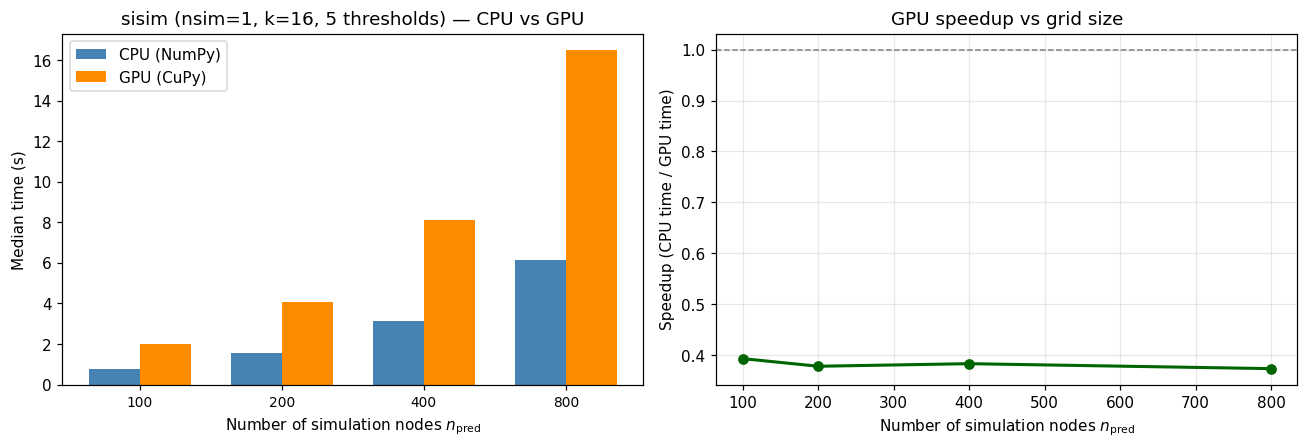

In [15]:
N_REPEATS = 3
PRED_SIZES = [100, 200, 400, 800]
K = 16
RADIUS = 1200.0
SEED = 7

grid_xy = pd.read_csv("../data/meuse_grid.csv")[["x", "y"]].to_numpy(dtype=float)
n_cond = len(df)

print("Meuse zinc sequential indicator simulation")
print(f"  conditioning : {n_cond} samples from data/meuse.csv (zinc)")
print(f"  thresholds   : {len(thresholds)} ({[round(t, 1) for t in thresholds]})")
print(f"  grid         : prefixes of meuse_grid.csv ({len(grid_xy)} nodes, 40 m lattice)")
print(f"  neighbors    : k={K}; radius={RADIUS:.0f} m; nsim=1; ordinary kriging")
print()


def _time_sis(xy, use_gpu, repeats=N_REPEATS, warmup=True):
    """Median wall time of sisim (nsim=1)."""
    kw = dict(
        prediction_grid=xy, df=df, xx="x", yy="y", zz="zinc",
        thresholds=thresholds, global_cdf=global_cdf, vario=vario,
        num_points=K, radius=RADIUS, kriging_type="ordinary",
        nsim=1, seed=SEED, quiet=True, use_gpu=use_gpu,
    )
    if warmup:
        sisim(
            prediction_grid=xy[: min(40, len(xy))],
            **{k: v for k, v in kw.items() if k != "prediction_grid"},
        )
        if use_gpu:
            import cupy as cp
            cp.cuda.Device(0).synchronize()
    times = []
    last = None
    for _ in range(repeats):
        t0 = time.perf_counter()
        last = sisim(**kw)
        if use_gpu:
            import cupy as cp
            cp.cuda.Device(0).synchronize()
        times.append(time.perf_counter() - t0)
    return float(np.median(times)), last


print(f"GPU usable : {USE_GPU}")
print(f"Repeats    : {N_REPEATS}  (median wall time of sisim, nsim=1)")
print(f"n_cond     : {n_cond}  (Meuse samples)")
print(f"n_pred     : {PRED_SIZES}  (prefixes of meuse_grid.csv)")
print(f"neighbors  : {K}; radius={RADIUS:.0f}")
print()

rows = []
for n_pred in PRED_SIZES:
    xy = grid_xy[:n_pred]
    cpu_t, pred_cpu = _time_sis(xy, use_gpu=False)
    row = {
        "dataset": "Meuse zinc",
        "n_cond": n_cond,
        "n_pred": n_pred,
        "CPU (s)": cpu_t,
        "GPU (s)": np.nan,
        "speedup": np.nan,
        "match": "—",
    }
    if USE_GPU:
        gpu_t, pred_gpu = _time_sis(xy, use_gpu=True)
        row["GPU (s)"] = gpu_t
        row["speedup"] = cpu_t / gpu_t
        row["match"] = bool(np.allclose(pred_cpu, pred_gpu, rtol=1e-4, atol=1e-4))
        import cupy as cp
        cp.get_default_memory_pool().free_all_blocks()
    rows.append(row)

df_bench = pd.DataFrame(rows)
df_show = df_bench.copy()
df_show["CPU (s)"] = df_show["CPU (s)"].round(3)
df_show["GPU (s)"] = df_show["GPU (s)"].round(3)
df_show["speedup"] = df_show["speedup"].map(
    lambda x: "—" if pd.isna(x) else f"{x:.2f}×"
)
print(df_show[["dataset", "n_cond", "n_pred", "CPU (s)", "GPU (s)", "speedup", "match"]].to_string(index=False))
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
n_vals = df_bench["n_pred"].to_numpy()
cpu_s = df_bench["CPU (s)"].to_numpy()
gpu_s = df_bench["GPU (s)"].to_numpy()
labels = [str(int(n)) for n in n_vals]
x = np.arange(len(n_vals))
w = 0.36
axes[0].bar(x - w / 2, cpu_s, w, label="CPU (NumPy)", color="steelblue")
if USE_GPU and np.isfinite(gpu_s).all():
    axes[0].bar(x + w / 2, gpu_s, w, label="GPU (CuPy)", color="darkorange")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=9)
axes[0].set_xlabel(r"Number of simulation nodes $n_{\mathrm{pred}}$")
axes[0].set_ylabel("Median time (s)")
axes[0].set_title(f"sisim (nsim=1, k={K}, {len(thresholds)} thresholds) — CPU vs GPU")
axes[0].legend()

if USE_GPU:
    axes[1].plot(n_vals, df_bench["speedup"], "o-", color="darkgreen", lw=2)
    axes[1].axhline(1.0, color="grey", ls="--", lw=1)
    axes[1].set_xlabel(r"Number of simulation nodes $n_{\mathrm{pred}}$")
    axes[1].set_ylabel("Speedup (CPU time / GPU time)")
    axes[1].set_title("GPU speedup vs grid size")
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(
        0.5, 0.5,
        "GPU not usable in this environment\nCPU-only timings shown",
        ha="center", va="center", transform=axes[1].transAxes,
    )
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()


CPU and GPU realizations should **match** (`match = True`) for the same
seed. Measured on the RTX 2080 Ti this notebook runs on: speedup sits
around **0.37–0.39×** at every grid size tested (100 to 800 nodes) -- worse
than `sgsim`'s equivalent (~0.72–0.80×), because each node here kriges
`len(thresholds)` = 5 separate systems, so there are 5x as many small CuPy
dispatches per node. Wall time scales linearly with $n_{\mathrm{pred}}$ on
both backends. The GPU path is there for unusually large `num_points`; for
typical SIS neighbourhoods at `nsim=1`, keep the default `use_gpu=False` --
§12.2 is where GPU dispatch has a real shot at paying off.


### 12.2 Batching Realizations on the GPU (`nsim` ≥ 2)

Realizations don't depend on each other -- only nodes *within* one
realization do. `_simulate_batch` (used automatically when `use_gpu=True`
and `nsim >= 2`) runs all `nsim` realizations in lockstep: at each shared
step, for *each threshold*, all `nsim` local indicator-kriging systems are
stacked into one batched covariance build + `xp.linalg.solve`, instead of
one CuPy dispatch per node per threshold per realization. That should turn
§12.1's "always below 1×" into a real win once there is enough to batch --
though SIS has `len(thresholds)` times as many small systems to amortize
overhead across as `sgsim` does at the same `n_pred`.

This fixes the grid to `meuse_grid.csv`'s first 100 nodes (same `k=16`,
`radius=1200`, 5 thresholds) and scans `nsim` from 1 to 32, comparing:

- **CPU**: `nsim` independent calls to `_simulate_one` (unchanged).
- **GPU**: `nsim=1` still takes §12.1's per-node-per-threshold path;
  `nsim >= 2` takes `_simulate_batch`.

These calls are already long enough (seconds, not milliseconds) that
run-to-run variance is small next to the trend, so each `nsim` is timed
once rather than as a median of repeats. Because `_simulate_batch` solves
with a small ridge via `xp.linalg.solve` where the CPU path uses `lstsq`
(see `_simulate_batch`'s docstring), and that per-node difference compounds
through `_ordrel`/`_beyond_zval` and the sequential conditioning set, CPU
and GPU realizations are compared with a looser tolerance
(`atol=rtol=1e-2`) than an exact match. A quick diagnostic at the end times
`_octant_search` itself (the per-realization, pandas-based neighbor lookup
that batching does *not* touch) against total wall time, to show what
actually caps the achievable speedup.


n_pred     : 100  (fixed, first 100 nodes of meuse_grid.csv)
neighbors  : k=16; radius=1200; thresholds=5
nsim       : [1, 2, 4, 8, 16, 32]

 nsim  CPU (s)  GPU (s) speedup  match
    1    0.771    1.972   0.39×   True
    2    1.533    2.094   0.73×   True
    4    3.048    3.364   0.91×   True
    8    6.113    6.049   1.01×   True
   16   12.054   11.449   1.05×   True
   32   24.086   21.859   1.10×   True

At nsim=32: octant search (CPU, pandas, per-realization) took 19.16s of 21.90s total (87%) -- batching the GPU solve doesn't touch this, so it caps how much §12.2's batching can win.
✅ [PASS] GPU realization-batching speedup grows with nsim  speedup at nsim=1: 0.39x, at nsim=32: 1.10x


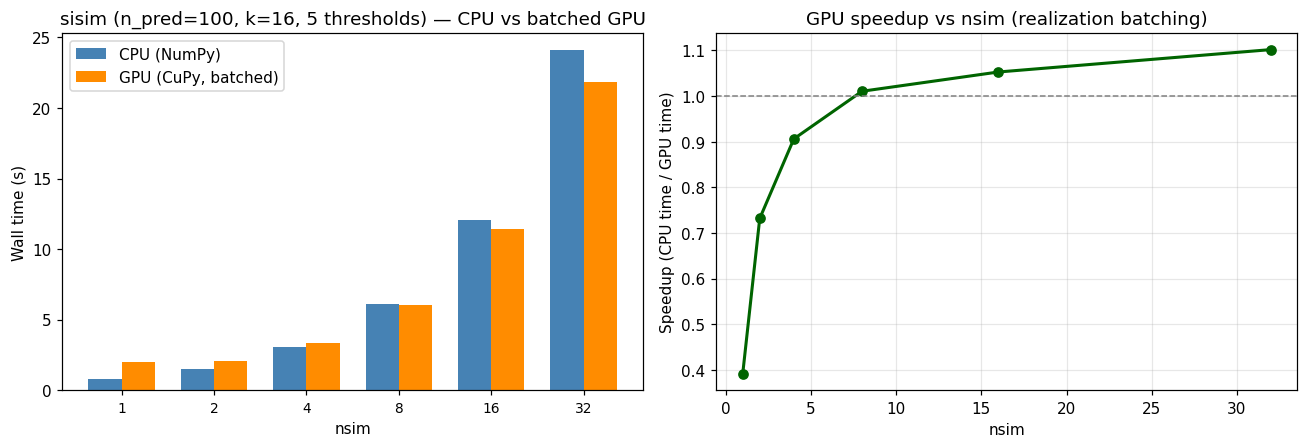

In [16]:
import importlib

NSIM_LIST = [1, 2, 4, 8, 16, 32]
N_PRED_NSIM = 100
grid_xy_nsim = grid_xy[:N_PRED_NSIM]

print(f"n_pred     : {N_PRED_NSIM}  (fixed, first {N_PRED_NSIM} nodes of meuse_grid.csv)")
print(f"neighbors  : k={K}; radius={RADIUS:.0f}; thresholds={len(thresholds)}")
print(f"nsim       : {NSIM_LIST}")
print()


def _time_sis_nsim(nsim, use_gpu):
    """Single-call wall time of sisim at a given nsim."""
    kw = dict(
        prediction_grid=grid_xy_nsim, df=df, xx="x", yy="y", zz="zinc",
        thresholds=thresholds, global_cdf=global_cdf, vario=vario,
        num_points=K, radius=RADIUS, kriging_type="ordinary",
        nsim=nsim, seed=SEED, quiet=True, use_gpu=use_gpu,
    )
    t0 = time.perf_counter()
    out = sisim(**kw)
    if use_gpu:
        import cupy as cp
        cp.cuda.Device(0).synchronize()
    return time.perf_counter() - t0, out


rows_nsim = []
for nsim in NSIM_LIST:
    cpu_t, out_cpu = _time_sis_nsim(nsim, use_gpu=False)
    row = {"nsim": nsim, "CPU (s)": cpu_t, "GPU (s)": np.nan, "speedup": np.nan, "match": "—"}
    if USE_GPU:
        gpu_t, out_gpu = _time_sis_nsim(nsim, use_gpu=True)
        row["GPU (s)"] = gpu_t
        row["speedup"] = cpu_t / gpu_t
        row["match"] = bool(np.allclose(out_cpu, out_gpu, rtol=1e-2, atol=1e-2))
        import cupy as cp
        cp.get_default_memory_pool().free_all_blocks()
    rows_nsim.append(row)

df_bench_nsim = pd.DataFrame(rows_nsim)
df_show_nsim = df_bench_nsim.copy()
df_show_nsim["CPU (s)"] = df_show_nsim["CPU (s)"].round(3)
df_show_nsim["GPU (s)"] = df_show_nsim["GPU (s)"].round(3)
df_show_nsim["speedup"] = df_show_nsim["speedup"].map(lambda x: "—" if pd.isna(x) else f"{x:.2f}×")
print(df_show_nsim.to_string(index=False))
print()

# Where does the time actually go? Time _octant_search itself (CPU, pandas,
# per-realization -- unaffected by GPU batching, and shared with sgsim) against
# total wall time at the largest nsim, on the GPU path.
if USE_GPU:
    _sgsim_mod = importlib.import_module("pygstat.sgsim")
    _orig_octant_search = _sgsim_mod._octant_search
    _octant_elapsed = {"total": 0.0}

    def _timed_octant_search(*args, **kwargs):
        _t0 = time.perf_counter()
        _result = _orig_octant_search(*args, **kwargs)
        _octant_elapsed["total"] += time.perf_counter() - _t0
        return _result

    _sgsim_mod._octant_search = _timed_octant_search
    try:
        _t0 = time.perf_counter()
        sisim(prediction_grid=grid_xy_nsim, df=df, xx="x", yy="y", zz="zinc",
              thresholds=thresholds, global_cdf=global_cdf, vario=vario,
              num_points=K, radius=RADIUS, kriging_type="ordinary",
              nsim=NSIM_LIST[-1], seed=SEED, quiet=True, use_gpu=True)
        import cupy as cp
        cp.cuda.Device(0).synchronize()
        _total = time.perf_counter() - _t0
    finally:
        _sgsim_mod._octant_search = _orig_octant_search

    print(f"At nsim={NSIM_LIST[-1]}: octant search (CPU, pandas, per-realization) took "
          f"{_octant_elapsed['total']:.2f}s of {_total:.2f}s total "
          f"({100 * _octant_elapsed['total'] / _total:.0f}%) -- batching the GPU solve "
          f"doesn't touch this, so it caps how much §12.2's batching can win.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
n_vals = df_bench_nsim["nsim"].to_numpy()
cpu_s = df_bench_nsim["CPU (s)"].to_numpy()
gpu_s = df_bench_nsim["GPU (s)"].to_numpy()
x = np.arange(len(n_vals))
w = 0.36
axes[0].bar(x - w / 2, cpu_s, w, label="CPU (NumPy)", color="steelblue")
if USE_GPU and np.isfinite(gpu_s).all():
    axes[0].bar(x + w / 2, gpu_s, w, label="GPU (CuPy, batched)", color="darkorange")
axes[0].set_xticks(x)
axes[0].set_xticklabels([str(int(n)) for n in n_vals], fontsize=9)
axes[0].set_xlabel("nsim")
axes[0].set_ylabel("Wall time (s)")
axes[0].set_title(f"sisim (n_pred={N_PRED_NSIM}, k={K}, {len(thresholds)} thresholds) — CPU vs batched GPU")
axes[0].legend()

if USE_GPU:
    axes[1].plot(n_vals, df_bench_nsim["speedup"], "o-", color="darkgreen", lw=2)
    axes[1].axhline(1.0, color="grey", ls="--", lw=1)
    axes[1].set_xlabel("nsim")
    axes[1].set_ylabel("Speedup (CPU time / GPU time)")
    axes[1].set_title("GPU speedup vs nsim (realization batching)")
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, "GPU not usable in this environment\nCPU-only timings shown",
                 ha="center", va="center", transform=axes[1].transAxes)
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

record(
    "GPU realization-batching speedup grows with nsim",
    "PASS" if (not USE_GPU or df_bench_nsim["speedup"].iloc[-1] >= df_bench_nsim["speedup"].iloc[0]) else "FAIL",
    (f"speedup at nsim={NSIM_LIST[0]}: {df_bench_nsim['speedup'].iloc[0]:.2f}x, "
     f"at nsim={NSIM_LIST[-1]}: {df_bench_nsim['speedup'].iloc[-1]:.2f}x") if USE_GPU else "GPU not usable",
)


Realization batching turns §12.1's "always well below 1×" into roughly
break-even as `nsim` grows. Measured on the RTX 2080 Ti this notebook runs
on, at `n_pred=100`, `k=16`, 5 thresholds: **0.39×** at `nsim=1` climbing
to **1.10×** by `nsim=32` (re-running may shift these slightly; see the
printed table above for this run's own numbers). `match = True` at every
`nsim` confirms `_simulate_batch` and the CPU path agree within its
documented ridge/solve tolerance.

The ceiling on that speedup is the same as `sgsim`'s: `_octant_search` --
the per-realization, pandas-based neighbor lookup that GPU batching does
not touch. The diagnostic above measured it eating **≈87%** of total wall
time at `nsim=32` here (`sgsim` measured ≈89% under the same conditions --
consistent, since SIS's *extra* per-threshold kriging cost is exactly the
part that *is* batched, so it doesn't shift octant search's share by much).
So: `use_gpu=True` with a large `nsim` is worth trying and won't cost you
much (roughly break-even at worst), but a *big* win -- for `sisim` even
more than `sgsim`, since SIS pays the octant-search cost once per node
regardless of how many thresholds it then kriges -- would need
`_octant_search` off pandas, not further GPU work on the kriging solves.


***
## 13. Summary and Conclusions

- **Sequential indicator simulation** visits grid nodes along a random path,
  kriges the indicator ccdf at each node, corrects order-relation problems
  (`ordrel`), and draws a grade from that local distribution (`beyond`).
  Conditioning data are honoured exactly in every realization.
- **`pygstat.sisim`** is a 2-D port of GSLIB `sisim.for`, with per-threshold
  variograms, simple or ordinary kriging, and multiple realizations (`nsim`).
- On **Meuse zinc**, realizations on `meuse_grid.csv` stay in the sample
  range, and the E-type mean can be compared with ordinary indicator kriging.
- The **animation** of all realizations (Section 11.1) makes spatial
  uncertainty visible: areas that stay the same colour are well informed;
  areas that flicker between realizations are not.
- **Conditional quantile maps** (Section 11.2) summarize the same
  ensemble. High (yellow) values of the 0.1-quantile map are where zinc is
  *certainly large*; low (dark yellow) values of the 0.9-quantile map are
  where zinc is *certainly small*.
- **CPU / GPU.** Nodes within one realization can't be batched, and each
  node kriges once per threshold, so at `nsim=1` GPU dispatch is per-node-
  per-threshold and clearly *slower* than NumPy (~0.37–0.39× on this
  RTX 2080 Ti, §12.1). But realizations don't depend on each other: at
  `nsim >= 2`, `sisim(..., use_gpu=True)` batches all realizations' local
  kriging systems together, per threshold (§12.2), turning that into
  roughly break-even (~1.10× by `nsim=32` here). Even batched, octant
  search -- not the kriging solves -- dominates wall time (~87% at
  `nsim=32`), so the batched GPU path is a safe thing to try at large
  `nsim`, not yet a decisive win. Default remains `use_gpu=False`.

| Object | Role in this notebook |
|---|---|
| `sisim` | Sequential indicator simulation (GSLIB `sisim.for` port) |
| `_ordrel` / `_beyond_zval` | Order-relation correction and ccdf draw |
| `use_gpu` | Covariance + solve dispatch to CuPy; per-node-per-threshold at `nsim=1`, batched across realizations (per threshold) at `nsim>=2` (default `False`; roughly break-even to a modest win at typical $k$) |
| `IndicatorKriging` | E-type honesty check |
| q10 / q50 / q90 maps | Conditional quantile summary of spatial uncertainty |


***
## 14. Notes

- This is a faithful port of the **actual Fortran source**
  (`sisim.for` + `gslib/ordrel.for`, `gslib/beyond.for`, `gslib/powint.for`,
  `gslib/cova3.for`), unlike `sgsim.py` (whose `.exe` had no available
  source). The math in `_ordrel`, `_beyond_zval`, and `_powint` was checked
  line-by-line against the Fortran and is tested directly above (Sections 4-5),
  not just indirectly through the full simulation.
- Reuses `sgsim.py`'s covariance/rotation/octant-search engine, confirmed
  against `cova3.for` to use the identical practical-range convention. §12's
  GPU realization-batching (`_simulate_batch`) also reuses `sgsim.py`'s
  batched-covariance-system helper directly, extended with the extra
  per-threshold loop SIS needs.
- **Not implemented** (documented in the module docstring): 3D (2D only,
  matching pygstat elsewhere), super-block/multi-grid search speedups
  (replaced with octant search -- same results, not optimized for huge
  grids), multi-structure variograms per threshold, median-IK weight reuse,
  soft/Markov-Bayes data, and the tabulated-quantiles tail options
  (`ltail/middle/utail = 3` in the original, which need an external
  reference-distribution file).
- **Quantile-map interpretation** follows Goovaerts (1997, *Geostatistics
  for Natural Resources Evaluation*): high values of the 0.1-quantile map
  indicate locations that are certainly large; low values of the
  0.9-quantile map indicate locations that are certainly small.
